In [1]:
import pandas as pd

df = pd.read_csv("big_league_sequence_dataset.csv")

df.head()

,Timestamp,Close,High,Low,Open,Volume,Ticker,return,rolling_mean_20,rolling_volatility_20,...,volume_zscore_lag_1,return_zscore_lag_1,Close_lag_2,return_lag_2,volume_zscore_lag_2,return_zscore_lag_2,Close_lag_3,return_lag_3,volume_zscore_lag_3,return_zscore_lag_3
0,2021-07-02,136.426270,136.465253,134.272061,134.418268,78852600,AAPL,0.019596,128.547845,0.009285,...,-1.322982,-0.331151,133.502014,0.004621,-0.734480,0.001851,132.887924,0.011500,-0.624453,0.679600
1,2021-07-06,138.434296,139.535755,136.533532,136.533532,108181800,AAPL,0.014719,129.333497,0.009424,...,0.381188,1.534011,133.804214,0.002264,-1.322982,-0.331151,133.502014,0.004621,-0.734480,0.001851
2,2021-07-07,140.919876,141.231789,139.058097,139.915868,104911600,AAPL,0.017955,130.202488,0.009792,...,1.929403,0.916245,136.426270,0.019596,0.381188,1.534011,133.804214,0.002264,-1.322982,-0.331151
3,2021-07-08,139.623489,140.422778,137.118369,138.005397,105575500,AAPL,-0.009199,130.987653,0.010393,...,1.539656,1.154740,138.434296,0.014719,1.929403,0.916245,136.426270,0.019596,0.381188,1.534011
4,2021-07-09,141.446243,141.972603,139.048347,139.145828,99890800,AAPL,0.013055,131.913667,0.009952,...,1.406419,-1.465716,140.919876,0.017955,1.539656,1.154740,138.434296,0.014719,1.929403,0.916245


In [2]:
import pandas as pd
import numpy as np

from ta.trend import EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands, AverageTrueRange

# -----------------------------
# Load Original Dataset
# -----------------------------
df = pd.read_csv("big_league_sequence_dataset.csv")

print("Original Shape:", df.shape)
print(df.head())

# -----------------------------
# Sort correctly
# -----------------------------
df = df.sort_values(["Ticker", "Timestamp"]).reset_index(drop=True)

print("\nUnique Stocks:", df["Ticker"].nunique())
print(df["Ticker"].unique())

Original Shape: (61600, 27)
    Timestamp       Close        High         Low        Open     Volume  \
0  2021-07-02  136.426270  136.465253  134.272061  134.418268   78852600   
1  2021-07-06  138.434296  139.535755  136.533532  136.533532  108181800   
2  2021-07-07  140.919876  141.231789  139.058097  139.915868  104911600   
3  2021-07-08  139.623489  140.422778  137.118369  138.005397  105575500   
4  2021-07-09  141.446243  141.972603  139.048347  139.145828   99890800   

  Ticker    return  rolling_mean_20  rolling_volatility_20  ...  \
0   AAPL  0.019596       128.547845               0.009285  ...   
1   AAPL  0.014719       129.333497               0.009424  ...   
2   AAPL  0.017955       130.202488               0.009792  ...   
3   AAPL -0.009199       130.987653               0.010393  ...   
4   AAPL  0.013055       131.913667               0.009952  ...   

   volume_zscore_lag_1  return_zscore_lag_1  Close_lag_2  return_lag_2  \
0            -1.322982            -0.3

In [3]:
processed_data = []

for ticker, stock_df in df.groupby("Ticker"):

    stock_df = stock_df.copy()

    # -----------------------------
    # EMA
    # -----------------------------
    stock_df["EMA_20"] = EMAIndicator(
        close=stock_df["Close"],
        window=20
    ).ema_indicator()

    # -----------------------------
    # RSI
    # -----------------------------
    stock_df["RSI_14"] = RSIIndicator(
        close=stock_df["Close"],
        window=14
    ).rsi()

    # -----------------------------
    # MACD
    # -----------------------------
    macd = MACD(stock_df["Close"])

    stock_df["MACD"] = macd.macd()

    stock_df["MACD_Signal"] = macd.macd_signal()

    stock_df["MACD_Hist"] = macd.macd_diff()

    # -----------------------------
    # Bollinger Bands
    # -----------------------------
    bb = BollingerBands(
        close=stock_df["Close"],
        window=20,
        window_dev=2
    )

    stock_df["BB_Upper"] = bb.bollinger_hband()
    stock_df["BB_Middle"] = bb.bollinger_mavg()
    stock_df["BB_Lower"] = bb.bollinger_lband()

    # -----------------------------
    # ATR
    # -----------------------------
    atr = AverageTrueRange(
        high=stock_df["High"],
        low=stock_df["Low"],
        close=stock_df["Close"],
        window=14
    )

    stock_df["ATR_14"] = atr.average_true_range()

    # -----------------------------
    # Remove NaNs created
    # by indicators
    # -----------------------------
    stock_df = stock_df.dropna()

    processed_data.append(stock_df)

# ---------------------------------------
# Combine all stocks back together
# ---------------------------------------

df = pd.concat(processed_data, ignore_index=True)

# Final ordering
df = df.sort_values(
    ["Ticker", "Timestamp"]
).reset_index(drop=True)

print(df.shape)

df.head()

(59950, 36)


,Timestamp,Close,High,Low,Open,Volume,Ticker,return,rolling_mean_20,rolling_volatility_20,...,return_zscore_lag_3,EMA_20,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR_14
0,2021-08-19,143.210342,144.479421,141.062678,141.580070,86960300,AAPL,0.002323,143.578587,0.010431,...,1.025797,143.460980,50.954832,1.030773,1.097588,-0.066815,146.897493,143.578587,140.259681,2.717037
1,2021-08-20,144.664902,144.967525,143.288439,143.932743,60549600,AAPL,0.010157,143.571377,0.010328,...,-0.862466,143.575639,55.311008,1.004900,1.079051,-0.074151,146.880169,143.571377,140.262585,2.648476
2,2021-08-23,146.148773,146.617351,144.372059,144.782067,60131800,AAPL,0.010257,143.617402,0.010565,...,-2.439993,143.820699,59.284051,1.091548,1.081550,0.009998,147.040729,143.617402,140.194075,2.619677
3,2021-08-24,146.060867,147.271376,145.602046,145.894913,48606400,AAPL,-0.000601,143.767226,0.009943,...,0.213821,144.034049,58.949693,1.139983,1.093237,0.046746,147.339665,143.767226,140.194788,2.551795
4,2021-08-25,144.830887,146.744270,144.284210,146.246392,58991300,AAPL,-0.008421,143.942795,0.009711,...,0.983296,144.109938,54.332311,1.066821,1.087954,-0.021132,147.358500,143.942795,140.527090,2.545243


In [4]:
indicator_columns = [
    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
    "BB_Upper",
    "BB_Middle",
    "BB_Lower",
    "ATR_14"
]

print(df[indicator_columns].describe())

print("\nRemaining NaNs")

print(df[indicator_columns].isna().sum())

             EMA_20        RSI_14          MACD   MACD_Signal     MACD_Hist  \
count  59950.000000  59950.000000  59950.000000  59950.000000  59950.000000   
mean     206.867495     52.240857      0.726934      0.709342      0.017592   
std      176.790865     12.589253      6.128017      5.695747      1.842686   
min        8.791608      9.151864    -55.079443    -52.379023    -19.137601   
25%       85.583062     43.014595     -1.359307     -1.242991     -0.530128   
50%      154.234995     52.113312      0.305430      0.295218      0.006694   
75%      277.658177     61.370439      2.447945      2.331648      0.562829   
max     1062.901291     94.222593    101.832442     85.422920     26.590466   

           BB_Upper     BB_Middle      BB_Lower        ATR_14  
count  59950.000000  59950.000000  59950.000000  59950.000000  
mean     220.011078    206.844626    193.678175      5.337243  
std      187.820026    176.870025    166.547946      4.986923  
min        9.055344      8.59372

In [5]:
df.to_csv(
    "big_league_with_indicators.csv",
    index=False
)

print("Saved Successfully")

print(df.shape)

Saved Successfully
(59950, 36)


In [6]:
from sklearn.preprocessing import MinMaxScaler

# ----------------------------------------
# Features for LSTM
# ----------------------------------------

features = [

    "Open",
    "High",
    "Low",
    "Close",
    "Volume",

    "return",
    "rolling_mean_20",
    "rolling_volatility_20",
    "high_low_spread",
    "momentum",
    "volume_change",
    "volume_zscore",
    "return_zscore",

    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
    "BB_Upper",
    "BB_Middle",
    "BB_Lower",
    "ATR_14"

]

target = "Close"

sequence_length = 30

print("Number of Features:", len(features))

Number of Features: 22


In [7]:
X_sequences = []
y_sequences = []

sequence_tickers = []
sequence_dates = []

feature_scalers = {}
target_scalers = {}

# -------------------------------------------------
# Process each stock independently
# -------------------------------------------------

for ticker, stock_df in df.groupby("Ticker"):

    stock_df = stock_df.copy()

    # -----------------------------
    # Feature scaler
    # -----------------------------

    feature_scaler = MinMaxScaler()

    X_scaled = feature_scaler.fit_transform(
        stock_df[features]
    )

    # -----------------------------
    # Target scaler
    # -----------------------------

    target_scaler = MinMaxScaler()

    y_scaled = target_scaler.fit_transform(
        stock_df[[target]]
    )

    # Save scalers
    feature_scalers[ticker] = feature_scaler
    target_scalers[ticker] = target_scaler

    # -----------------------------
    # Sliding Window
    # -----------------------------

    for i in range(sequence_length, len(stock_df)):

        X_sequences.append(
            X_scaled[i-sequence_length:i]
        )

        y_sequences.append(
            y_scaled[i]
        )

        sequence_tickers.append(ticker)

        sequence_dates.append(
            stock_df.iloc[i]["Timestamp"]
        )

# Convert to arrays

X_sequences = np.array(X_sequences)

y_sequences = np.array(y_sequences)

sequence_tickers = np.array(sequence_tickers)

sequence_dates = np.array(sequence_dates)

print("Input Shape :", X_sequences.shape)
print("Target Shape:", y_sequences.shape)

Input Shape : (58450, 30, 22)
Target Shape: (58450, 1)


In [8]:
from sklearn.model_selection import train_test_split

(
    X_train,
    X_test,
    y_train,
    y_test,
    ticker_train,
    ticker_test,
    date_train,
    date_test

) = train_test_split(

    X_sequences,
    y_sequences,

    sequence_tickers,
    sequence_dates,

    test_size=0.2,

    shuffle=False

)

print("Training Samples :", X_train.shape[0])

print("Testing Samples  :", X_test.shape[0])

Training Samples : 46760
Testing Samples  : 11690


In [9]:
print("="*60)

print("Training")

print("X:", X_train.shape)

print("y:", y_train.shape)

print()

print("Testing")

print("X:", X_test.shape)

print("y:", y_test.shape)

print()

print("One Sample Shape")

print(X_train[0].shape)

print()

print("Unique Stocks in Training")

print(len(np.unique(ticker_train)))

print()

print("Unique Stocks in Testing")

print(len(np.unique(ticker_test)))

Training
X: (46760, 30, 22)
y: (46760, 1)

Testing
X: (11690, 30, 22)
y: (11690, 1)

One Sample Shape
(30, 22)

Unique Stocks in Training
40

Unique Stocks in Testing
10


In [10]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [11]:
model = Sequential([

    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(
        32
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,233 (137.63 KB)

 Trainable params: 35,233 (137.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(

    optimizer="adam",

    loss="mean_squared_error",

    metrics=["mae"]

)

print("Model Compiled Successfully")

Model Compiled Successfully


In [13]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

history = model.fit(X_train,y_train,
    validation_data=(
        X_test,
        y_test
    ),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0046 - mae: 0.0448 - val_loss: 0.0012 - val_mae: 0.0243 - learning_rate: 0.0010
Epoch 2/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0016 - mae: 0.0292 - val_loss: 0.0015 - val_mae: 0.0289 - learning_rate: 0.0010
Epoch 3/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0011 - mae: 0.0244 - val_loss: 0.0016 - val_mae: 0.0305 - learning_rate: 0.0010
Epoch 4/50
729/731 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.1717e-04 - mae: 0.0222
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
731/731 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 8.6779e-04 - mae: 0.0217 - val_loss: 0.0018 - val_mae: 0.0317 - learning_rate: 0.0010
Epoch 5/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 7.4920e-04 - mae: 0.0200 - val_loss: 0.0033 - val_mae: 0.0430 - learning_rate: 5.0000e-04
Epoch 6/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 7.0924e-04 - mae: 0.0194 - val_loss: 0.0019 - val_mae: 0.03

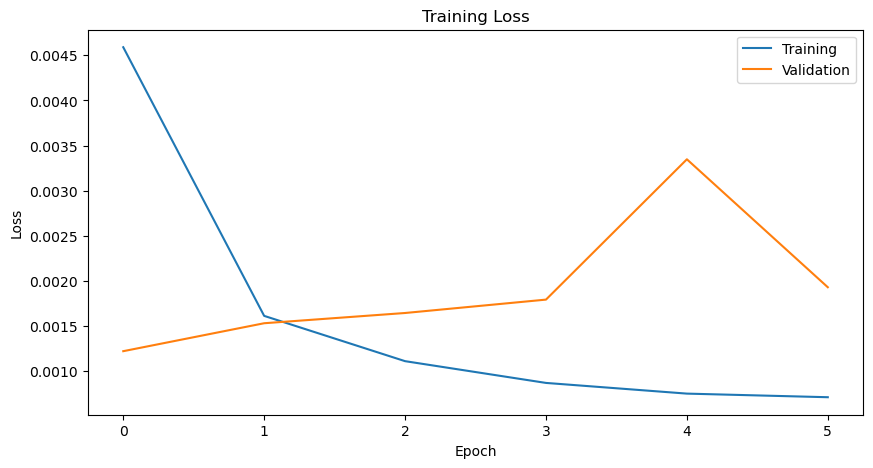

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training"
)
plt.plot(
    history.history["val_loss"],
    label="Validation"
)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
model.save("multi_stock_lstm.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [16]:
# Generate predictions
y_pred_scaled = model.predict(X_test)

print("Prediction Shape :", y_pred_scaled.shape)
print("Actual Shape     :", y_test.shape)

366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction Shape : (11690, 1)
Actual Shape     : (11690, 1)


In [17]:
# Convert predictions back to original stock prices
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_actual = target_scaler.inverse_transform(y_test)

print("First 5 Actual Prices:")
print(y_actual[:5])

print("\nFirst 5 Predicted Prices:")
print(y_pred[:5])

First 5 Actual Prices:
[[105.20996433]
 [103.44921909]
 [103.10401461]
 [102.06826625]
 [104.55395776]]

First 5 Predicted Prices:
[[106.99817 ]
 [106.273026]
 [105.24338 ]
 [104.38121 ]
 [103.29051 ]]


In [18]:
import numpy as np

y_actual = []
y_pred = []

for i in range(len(y_test)):

    ticker = ticker_test[i]

    scaler = target_scalers[ticker]

    actual = scaler.inverse_transform(
        y_test[i].reshape(-1,1)
    )[0][0]

    pred = scaler.inverse_transform(
        y_pred_scaled[i].reshape(-1,1)
    )[0][0]

    y_actual.append(actual)
    y_pred.append(pred)

y_actual = np.array(y_actual)
y_pred = np.array(y_pred)

print("Inverse Transform Complete")

Inverse Transform Complete


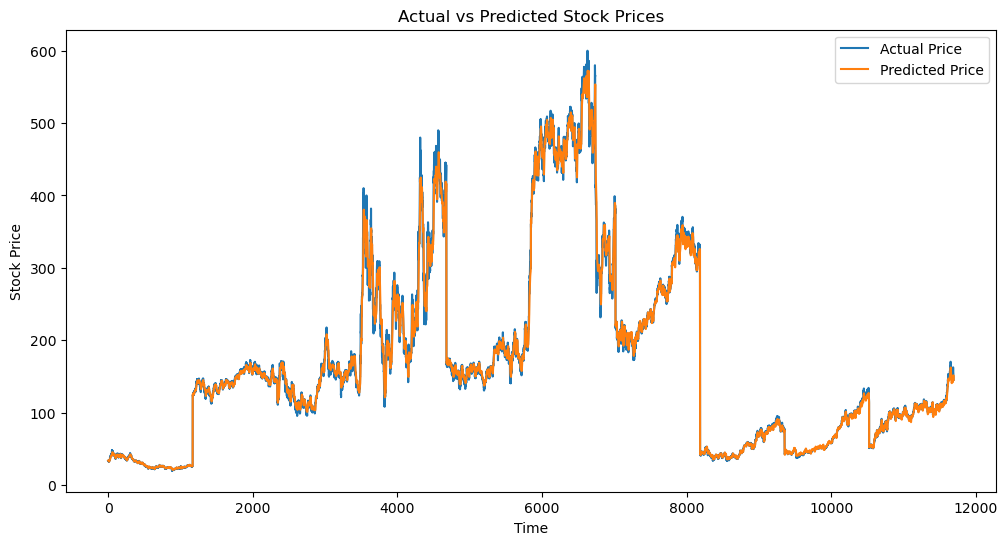

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(y_actual, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE  : 4.41
RMSE : 8.34


In [21]:
prediction_error = np.abs(
    y_actual - y_pred
)
results = pd.DataFrame({
    "Ticker": ticker_test,
    "Timestamp": date_test,
    "Actual": y_actual,
    "Predicted": y_pred,
    "Error": prediction_error
})

results.head()

,Ticker,Timestamp,Actual,Predicted,Error
0,PFE,2021-10-01,33.526100,33.930599,0.404499
1,PFE,2021-10-04,33.127811,33.766571,0.638760
2,PFE,2021-10-05,33.049725,33.533657,0.483932
3,PFE,2021-10-06,32.815434,33.338631,0.523197
4,PFE,2021-10-07,33.377708,33.091911,0.285797


In [22]:
threshold = (
    results["Error"].mean()
    +
    2*results["Error"].std()
)

print("Threshold:", threshold)

print(
    "Anomalies:",
    (results["Error"]>threshold).sum()
)

Threshold: 18.570120877142713
Anomalies: 498


In [23]:
results["Anomaly"] = (
    results["Error"] > threshold
)

results.head()

,Ticker,Timestamp,Actual,Predicted,Error,Anomaly
0,PFE,2021-10-01,33.526100,33.930599,0.404499,False
1,PFE,2021-10-04,33.127811,33.766571,0.638760,False
2,PFE,2021-10-05,33.049725,33.533657,0.483932,False
3,PFE,2021-10-06,32.815434,33.338631,0.523197,False
4,PFE,2021-10-07,33.377708,33.091911,0.285797,False


In [24]:
top_anomalies = results.sort_values(

    "Error",

    ascending=False

)

top_anomalies.head(20)

,Ticker,Timestamp,Actual,Predicted,Error,Anomaly
6735,UNH,2025-04-21,411.316101,534.851074,123.534973,True
6734,UNH,2025-04-17,439.147888,553.227173,114.079285,True
6753,UNH,2025-05-15,265.310669,365.391113,100.080444,True
6736,UNH,2025-04-22,413.105164,512.562622,99.457458,True
6751,UNH,2025-05-13,301.120544,391.487579,90.367035,True
4289,TSLA,2024-11-11,350.000000,269.094360,80.905640,True
6752,UNH,2025-05-14,297.861633,378.386353,80.524719,True
6737,UNH,2025-04-23,413.859497,491.027374,77.167877,True
4314,TSLA,2024-12-17,479.859985,405.261749,74.598236,True
4313,TSLA,2024-12-16,463.019989,394.423065,68.596924,True


# SHAP analysis


In [27]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
# Use a small background dataset
background_size = 100

background = X_train[
    np.random.choice(
        X_train.shape[0],
        background_size,
        replace=False
    )
]

explainer = shap.GradientExplainer(
    model,
    background
)

print("Gradient SHAP Ready")

Gradient SHAP Ready


In [29]:
feature_names = [

    "Open",
    "High",
    "Low",
    "Close",
    "Volume",

    "Return",
    "Rolling_Mean_20",
    "Rolling_Volatility_20",
    "High_Low_Spread",
    "Momentum",
    "Volume_Change",
    "Volume_ZScore",
    "Return_ZScore",

    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
    "BB_Upper",
    "BB_Middle",
    "BB_Lower",
    "ATR_14"

]

In [34]:
top_features = []
top_scores = []

anomaly_indices = results.index[
    results["Anomaly"]
].tolist()

for idx in anomaly_indices:
    sample = X_test[idx:idx+1]
    
    shap_values = explainer.shap_values(sample)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    
    shap_values = np.array(shap_values)
    
    # (1,30,22,1) -> (30,22)
    shap_values = shap_values[0, :, :, 0]
    
    # Aggregate over time
    importance = np.max(
        np.abs(shap_values),
        axis=0
    )
    
    order = np.argsort(importance)[::-1]
    
    top_features.append(
        [feature_names[i] for i in order[:5]]
    )
    
    top_scores.append(
        [float(importance[i]) for i in order[:5]]
    )
print("Finished SHAP Analysis")

Finished SHAP Analysis


# Add Explanations


In [36]:
anomaly_rows = results.index[
    results["Anomaly"]
]

for row_idx, result_idx in enumerate(anomaly_rows):

    for j in range(5):

        results.loc[
            result_idx,
            f"Top_Feature_{j+1}"
        ] = top_features[row_idx][j]

        results.loc[
            result_idx,
            f"Importance_{j+1}"
        ] = top_scores[row_idx][j]

results.to_csv(
    "Explainable_Anomalies.csv",
    index=False
)

results[results["Anomaly"]].head()

,Ticker,Timestamp,Actual,Predicted,Error,Anomaly,Top_Feature_1,Importance_1,Top_Feature_2,Importance_2,Top_Feature_3,Importance_3,Top_Feature_4,Importance_4,Top_Feature_5,Importance_5
2363,QCOM,2021-11-05,147.030151,126.601639,20.428513,True,RSI_14,0.008889,Close,0.005722,High,0.005419,Open,0.004725,Return_ZScore,0.004309
3044,QCOM,2024-07-25,168.075867,187.278839,19.202972,True,Close,0.008063,EMA_20,0.007004,RSI_14,0.006729,Open,0.006489,High,0.006446
3047,QCOM,2024-07-30,159.978287,180.051361,20.073074,True,RSI_14,0.006863,Close,0.005892,EMA_20,0.005877,MACD_Hist,0.005422,Open,0.004445
3049,QCOM,2024-08-01,157.160873,175.808792,18.647919,True,RSI_14,0.008925,MACD_Hist,0.005868,EMA_20,0.005667,Close,0.005143,Open,0.003929
3050,QCOM,2024-08-02,152.666443,173.142426,20.475983,True,RSI_14,0.007594,MACD_Hist,0.005697,EMA_20,0.005362,Close,0.004222,MACD,0.003677


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 30, 22))']
  warnings.warn(msg)


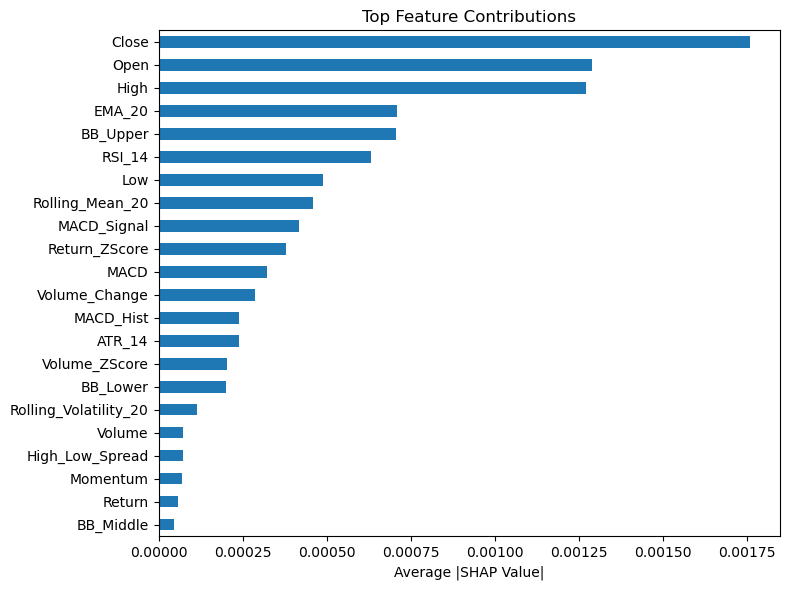

In [37]:
selected_idx = anomaly_indices[0]

sample = X_test[selected_idx:selected_idx+1]

shap_values = explainer.shap_values(sample)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.squeeze(np.array(shap_values))

importance = np.mean(
    np.abs(shap_values),
    axis=0
)

importance = pd.Series(
    importance,
    index=feature_names
).sort_values()

plt.figure(figsize=(8,6))

importance.plot.barh()

plt.title("Top Feature Contributions")

plt.xlabel("Average |SHAP Value|")

plt.tight_layout()

plt.show()